#Лабораторная работа 1.
    j3113 Мижа Виктория 466703

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


##Подключаю гугл драйв



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# I. Подготовка данных и базовые операции с NumPy

##Загрузка и подготовка данных:

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SeoulBikeData.csv', encoding='cp1256')
df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


##Изучаю данные

In [ ]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

####!мне не нужно ничего удалять, поскольку нет пропусков!

In [ ]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## Преобразование категориальных переменных в числовые

In [ ]:
le = LabelEncoder()
df['Seasons'] = le.fit_transform(df['Seasons'])
df['Holiday'] = le.fit_transform(df['Holiday'])
df['Functioning Day'] = le.fit_transform(df['Functioning Day'])
df


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,3,1,1
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,3,1,1
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,3,1,1
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,3,1,1
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,0,1,1
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,0,1,1
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,0,1,1
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   int64  
 12  Holiday                    8760 non-null   int64  
 13  Functioning Day            8760 non-null   int64

### Данные приведены к приемлемому формату

#Основные операции с NumPy:

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%Y")

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek

df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,year,month,day,dayofweek
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,3,1,1,2017,12,1,4
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,3,1,1,2017,12,1,4
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,3,1,1,2017,12,1,4
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,3,1,1,2017,12,1,4
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,3,1,1,2017,12,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,0,1,1,2018,11,30,4
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,0,1,1,2018,11,30,4
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,0,1,1,2018,11,30,4
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,0,1,1,2018,11,30,4


In [ ]:
df.describe()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,year,month,day,dayofweek
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2018-05-31 23:59:59.999999744,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,1.495890,0.950685,0.966324,2017.915068,6.526027,15.720548,3.002740
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2018.000000,4.000000,8.000000,1.000000
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,1.000000,1.000000,1.000000,2018.000000,7.000000,16.000000,3.000000
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,2.000000,1.000000,1.000000,2018.000000,10.000000,23.000000,5.000000
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000,3.000000,1.000000,1.000000,2018.000000,12.000000,31.000000,6.000000
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,1.114408,0.216537,0.180404,0.278796,3.448048,8.796749,1.998056


In [ ]:
bike_counts = df['Rented Bike Count']
temperature = df['Temperature(°C)']
humidity = df['Humidity(%)']
year = df['year']
month = df['month']
day = df['day']
dayofweek = df['dayofweek']

In [ ]:
bike_counts_vector = np.array(bike_counts)
temperature_vector = np.array(temperature)
humidity_vector = np.array(humidity)
year_vector = np.array(year)
month_vector = np.array(month)
day_vector = np.array(day)
dayofweek_vector = np.array(dayofweek)

In [ ]:

matrix = np.array([bike_counts_vector, temperature_vector, humidity_vector, year_vector, month_vector, day_vector, dayofweek_vector])
matrix

array([[254. , 204. , 173. , ..., 694. , 712. , 584. ],
       [ -5.2,  -5.5,  -6. , ...,   2.6,   2.1,   1.9],
       [ 37. ,  38. ,  39. , ...,  39. ,  41. ,  43. ],
       ...,
       [ 12. ,  12. ,  12. , ...,  11. ,  11. ,  11. ],
       [  1. ,   1. ,   1. , ...,  30. ,  30. ,  30. ],
       [  4. ,   4. ,   4. , ...,   4. ,   4. ,   4. ]])

## Индексация и срезы:

In [ ]:
matrix[:, matrix[3] == 2018]

array([[206. , 230. , 178. , ..., 694. , 712. , 584. ],
       [ -3.2,  -3.3,  -3.7, ...,   2.6,   2.1,   1.9],
       [ 40. ,  41. ,  42. , ...,  39. ,  41. ,  43. ],
       ...,
       [  1. ,   1. ,   1. , ...,  11. ,  11. ,  11. ],
       [  1. ,   1. ,   1. , ...,  30. ,  30. ,  30. ],
       [  0. ,   0. ,   0. , ...,   4. ,   4. ,   4. ]])

In [ ]:
for i in range(7):
  print(f'День недели {i + 1}')
  print(matrix[:, matrix[-1] == i])

День недели 1
[[285.  186.  112.  ... 955.  846.  563. ]
 [  4.2   4.3   4.4 ...   6.7   6.2   5.4]
 [ 88.   87.   87.  ...  71.   70.   78. ]
 ...
 [ 12.   12.   12.  ...  11.   11.   11. ]
 [  4.    4.    4.  ...  26.   26.   26. ]
 [  0.    0.    0.  ...   0.    0.    0. ]]
День недели 2
[[216.  198.  124.  ... 777.  740.  593. ]
 [ -6.1  -6.5  -6.8 ...   7.5   6.6   5.8]
 [ 42.   41.   41.  ...  35.   33.   34. ]
 ...
 [ 12.   12.   12.  ...  11.   11.   11. ]
 [  5.    5.    5.  ...  27.   27.   27. ]
 [  1.    1.    1.  ...   1.    1.    1. ]]
День недели 3
[[145.  144.  117.  ... 846.  804.  555. ]
 [ -2.8  -3.   -3.  ...   4.2   3.2   2.9]
 [ 77.   79.   79.  ...  31.   34.   31. ]
 ...
 [ 12.   12.   12.  ...  11.   11.   11. ]
 [  6.    6.    6.  ...  28.   28.   28. ]
 [  2.    2.    2.  ...   2.    2.    2. ]]
День недели 4
[[198.  218.  149.  ... 792.  726.  559. ]
 [  1.4   1.5   1.4 ...   3.8   3.    2.6]
 [ 92.   92.   92.  ...  55.   59.   56. ]
 ...
 [ 12.   12.   12.

# II. Операции с векторами и матрицами


## Операции над векторами:

Cложение векторов

In [ ]:
temperature_vector

array([-5.2, -5.5, -6. , ...,  2.6,  2.1,  1.9])

In [ ]:
humidity_vector

array([37, 38, 39, ..., 39, 41, 43])

In [ ]:
temperature_vector + humidity_vector

array([31.8, 32.5, 33. , ..., 41.6, 43.1, 44.9])

Вычитание векторов

In [ ]:
year_vector

array([2017, 2017, 2017, ..., 2018, 2018, 2018], dtype=int32)

In [ ]:
day_vector

array([ 1,  1,  1, ..., 30, 30, 30], dtype=int32)

In [ ]:
year_vector - day_vector

array([2016, 2016, 2016, ..., 1988, 1988, 1988], dtype=int32)

Скалярное произведение векторов

In [ ]:
bike_counts_vector


array([254, 204, 173, ..., 694, 712, 584])

In [ ]:
temperature_vector

array([-5.2, -5.5, -6. , ...,  2.6,  2.1,  1.9])

In [ ]:
bike_counts_vector * temperature_vector

array([-1320.8, -1122. , -1038. , ...,  1804.4,  1495.2,  1109.6])

# III. Анализ сходства между векторами

## Корреляция и косинусное сходство:

In [ ]:
def pearson_correlation(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2)) * np.sqrt(np.sum((y - y_mean)**2))

    if denominator == 0:
        return 0

    return numerator / denominator

answer = pearson_correlation(bike_counts_vector, humidity_vector)
answer

-0.19978016700089832

In [ ]:
correct = np.corrcoef(bike_counts_vector, humidity_vector)[0, 1]
correct

-0.19978016700089823

Проверка

In [ ]:
answer / correct

1.0000000000000004

In [ ]:
def cosine_similarity(x, y):
    dot_product = np.dot(x, y)
    norm_x = np.linalg.norm(x)
    norm_y = np.linalg.norm(y)

    if norm_x == 0 or norm_y == 0:
        return 0

    return dot_product / (norm_x * norm_y)

answer = cosine_similarity(bike_counts_vector, humidity_vector)
answer

0.6517644015134372

##Нормализация векторов:

In [ ]:
def normalize_vector(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        return v
    return v / norm

normalize_vector(bike_counts_vector)

array([0.00284106, 0.00228179, 0.00193505, ..., 0.00776257, 0.00796391,
       0.00653219])

Чтобы сравнить два вектора (bike_counts_vector и humidity_vector) и найти их сходство можно просто вычислить косинусное сходство между ними.


# Прогнозирование и кластеризация

## Фильтрация временных рядов:

In [ ]:
def moving_average_filter(time_series, window_size):
    kernel = np.ones(window_size) / window_size  # Ядро для скользящего среднего
    smoothed_series = np.convolve(time_series, kernel, mode='valid')
    return smoothed_series

window_size = 7  # Размер окна
smoothed_series = moving_average_filter(bike_counts, window_size)
smoothed_series

array([156.71428571, 186.14285714, 289.85714286, ..., 928.14285714,
       920.14285714, 884.        ])

<Axes: >

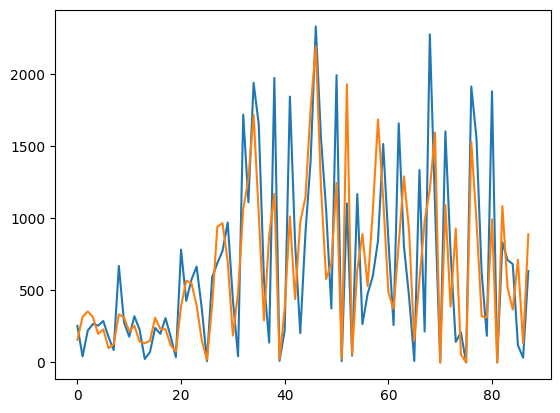

In [ ]:
sns.lineplot(bike_counts_vector[::100])
sns.lineplot(smoothed_series[::100])

### Эксперименты с разными ядрами

In [ ]:
def gaussian_kernel(size, sigma=1):
    x = np.arange(size)
    center = size // 2
    kernel = np.exp(-(x - center)**2 / (2 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel
gaussian_kernel_7 = gaussian_kernel(size=7, sigma=1)
gaussian_kernel_7

array([0.00443305, 0.05400558, 0.24203623, 0.39905028, 0.24203623,
       0.05400558, 0.00443305])

<Axes: >

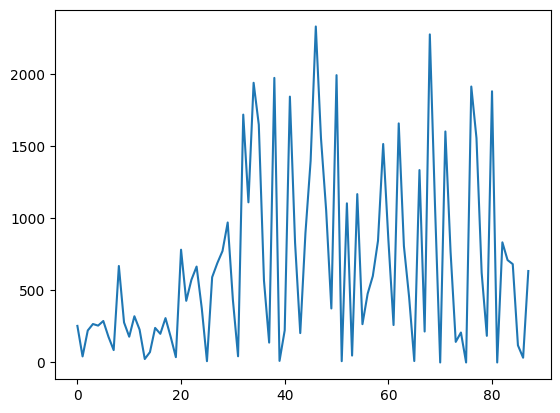

In [ ]:
sns.lineplot(bike_counts_vector[::100])
sns.lineplot(gaussian_kernel_7[::100])

###Кластеризация методом k-средних:



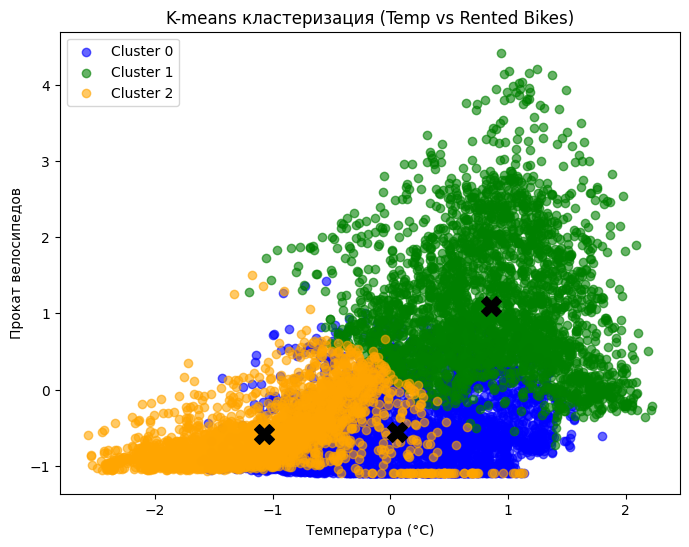

-0.6986504580732504

In [ ]:
features = df[['Rented Bike Count','Temperature(°C)', 'Humidity(%)']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)




def k_means_numpy(data, k, max_iters=100, tol=1e-4):
  centroids = data[np.random.choice(len(data), k, replace=False)]
  for _ in range(max_iters):
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    clusters = np.argmin(distances, axis=1)
    new_centroids = np.array([data[clusters == i].mean(axis=0) if np.any(clusters == i) else centroids[i] for i in range(k)])
    if np.all(np.abs(new_centroids - centroids) < tol):
       break
    centroids = new_centroids

  return clusters, centroids

k = 3
labels, centers = k_means_numpy(features_scaled, k)

cluster_colors = ['blue', 'green', 'orange', 'red', 'purple']

plt.figure(figsize=(8, 6))

for c in np.unique(labels):
    plt.scatter(
        features_scaled[labels == c, 1],
        features_scaled[labels == c, 0],  # Прокат велосипедов
        label=f'Cluster {c}',
        alpha=0.6,
        c=cluster_colors[c % len(cluster_colors)]
    )

# Отображаем центры кластеров
for idx, center in enumerate(centers):
    plt.scatter(center[1], center[0], s=200, marker='X', c='black')

plt.title('K-means кластеризация (Temp vs Rented Bikes)')
plt.xlabel('Температура (°C)')
plt.ylabel('Прокат велосипедов')
plt.legend()
plt.show()

np.unique(labels)
features_scaled[0, 0]

ValueError: s must be a scalar, or float array-like with the same size as x and y

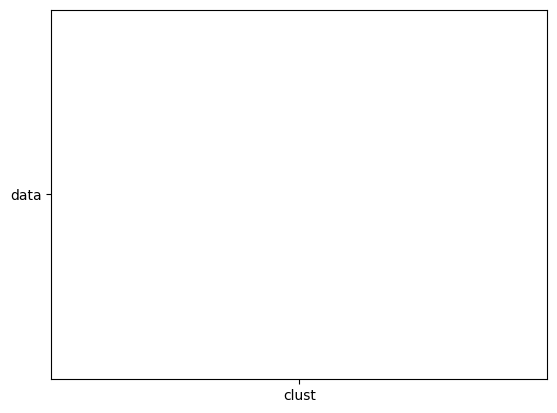

In [ ]:
np.random.seed(19680801)


N = 7
x = np.random.rand(N)
y = np.random.rand(N)
colors = np.random.rand(N)
area = (50 * np.random.rand(N))**2  # 0 to 15 point radii

labels = k_means_numpy(features_scaled, k)

bike_counts = df['Rented Bike Count'].values
plot_data = pd.DataFrame({'data': bike_counts, 'clust': labels})
plt.scatter(x = 'clust', y = 'data', s=area, c=colors, alpha=0.5)
plt.show()

<Axes: xlabel='clust', ylabel='data'>

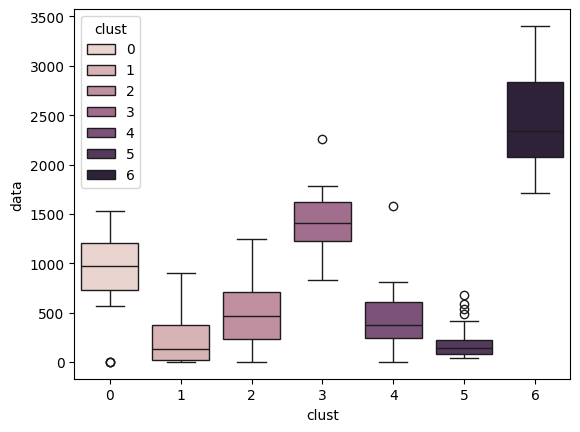

In [ ]:
k = 7
labels = k_means_numpy(features_scaled, k)

bike_counts = df['Rented Bike Count'].values
plot_data = pd.DataFrame({'data': bike_counts, 'clust': labels})
sns.boxplot(data = plot_data[::30], x = 'clust', y = 'data', hue = 'clust')

##Генерация случайных данных и анализ

In [ ]:
generation = np.random.randint(0, 3556, size=8760)
generation

array([2420, 1255,  856, ...,  715, 2911,  409])

Анализ случайных данных:

In [ ]:
pearson_correlation(bike_counts_vector, generation)

0.02785518047690288

In [ ]:
cosine_similarity(bike_counts_vector, generation)

0.6480435556235317

<Axes: >

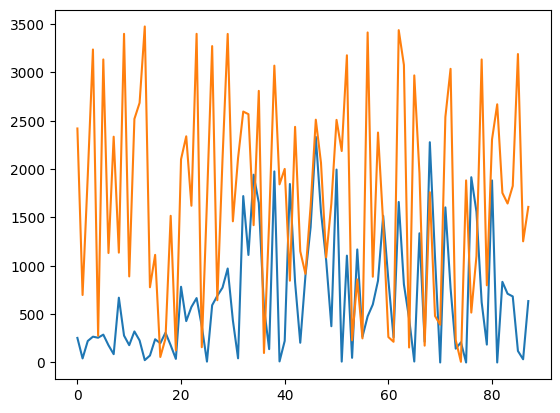

In [ ]:
sns.lineplot(bike_counts_vector[::100])
sns.lineplot(generation[::100])

##Вывод по лабораторной работе




###В ходе работы были успешно применены методы обработки и анализа данных с использованием библиотек NumPy, Pandas и Matplotlib. Реализованы алгоритмы для анализа сходства между векторами, фильтрации временных рядов и кластеризации данных. Проведена визуализация результатов, что позволило наглядно представить полученные данные и сделать выводы о взаимосвязи различных параметров. Работа показала, что использование современных инструментов и методов анализа данных позволяет эффективно решать задачи, связанные с обработкой и интерпретацией больших объемов информации.